# 0. 環境構築

In [2]:
%pip install -q bambi

Note: you may need to restart the kernel to use updated packages.


In [17]:
#-----------------------------------------------
#ライブラリのインポート
#-----------------------------------------------

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pymc as pm
import arviz_base as azb
import arviz_plots as azp
import arviz_stats as azs
import japanize_matplotlib
import seaborn as sns
import seaborn.objects as so
import bambi as bmb

%matplotlib inline

#-----------------------------------------------
#grapfvizの設定
#-----------------------------------------------

import os
import sys

# Graphvizの bin フォルダのパスを指定 (環境に合わせて変更してください)
graphviz_path = r"C:\Program Files\Graphviz\bin"

# PATHに一時的に追加
os.environ["PATH"] += os.pathsep + graphviz_path

# この後に graphviz や pydot を呼び出す
import graphviz

seed = 1221

# 1. データ準備
- チュートリアル
    - https://bambinos.github.io/bambi/notebooks/sleepstudy.html
- sleepstudy data
    - Days（睡眠不足の日数）が増加するほど、Reaction（反応までの時間）が長くなる実験

## 1-1. データのロード

In [4]:
data = bmb.load_data("sleepstudy")
data

,Reaction,Days,Subject
0,249.5600,0,308
1,258.7047,1,308
2,250.8006,2,308
3,321.4398,3,308
4,356.8519,4,308
...,...,...,...
175,329.6076,5,372
176,334.4818,6,372
177,343.2199,7,372
178,369.1417,8,372


## 1-2. データの可視化（sns.objects）
- https://seaborn.pydata.org/tutorial/objects_interface.html

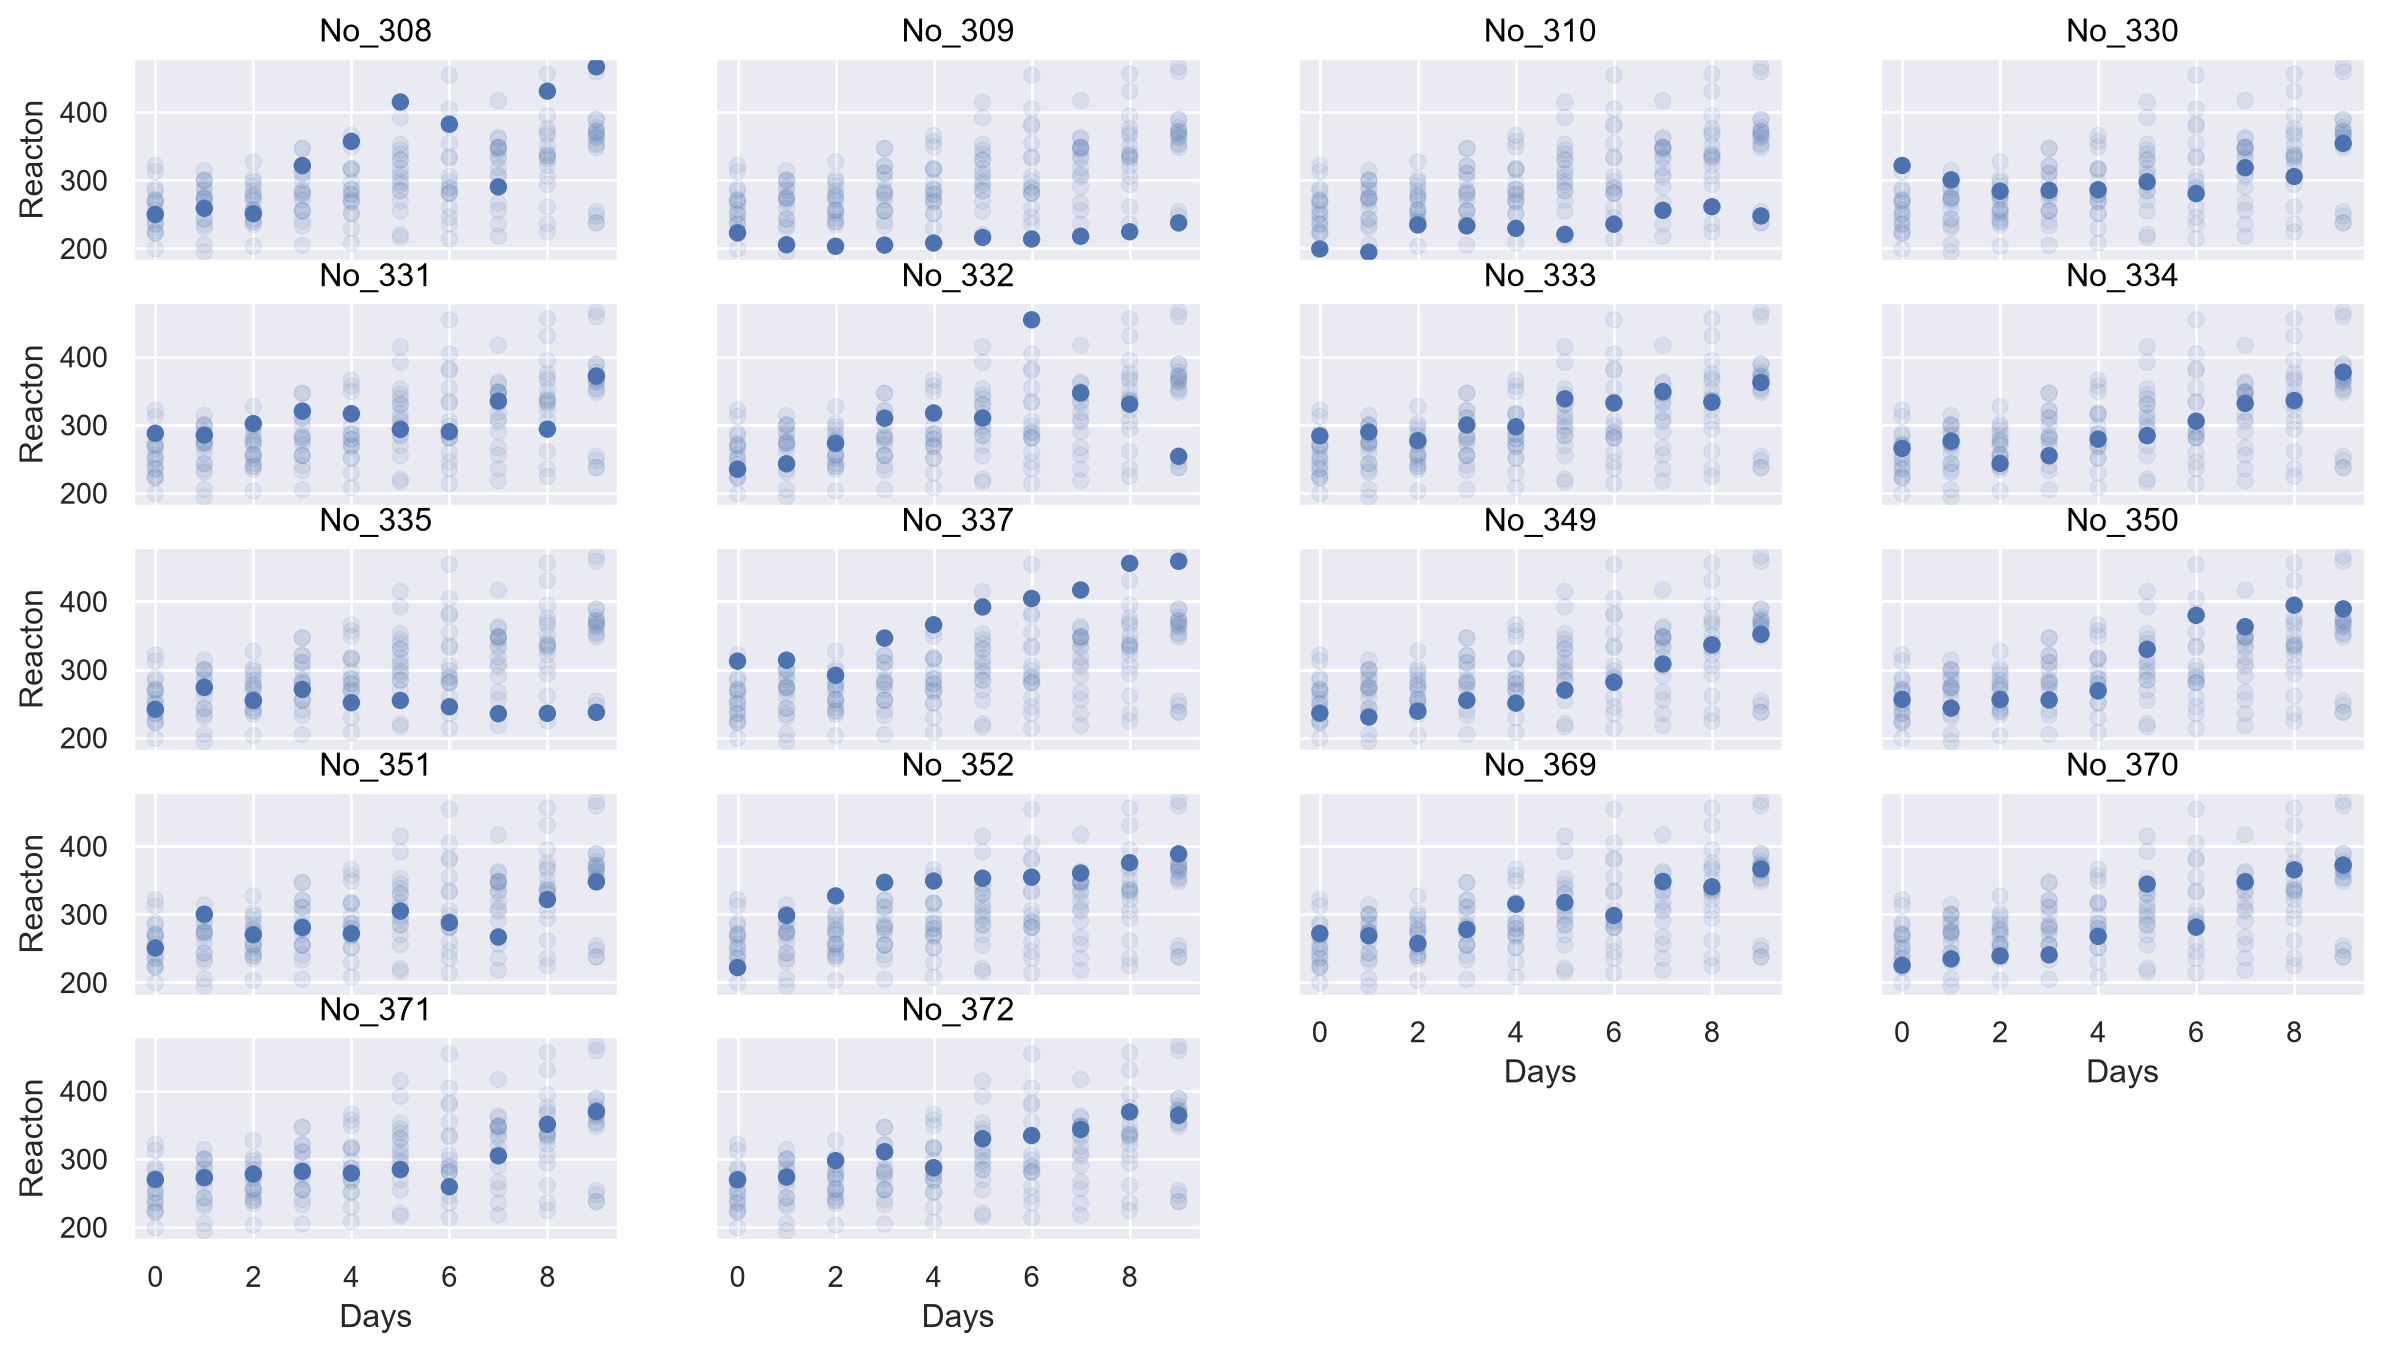

In [5]:
import matplotlib
f = matplotlib.figure.Figure(figsize=(15, 8))

(
    so.Plot(data, x="Days", y="Reaction")
    .facet("Subject", wrap=4)
    .add(so.Dot(alpha=.1), group="Subject", col=None) #重ね書き
    .add(so.Dot())
    .on(f)
    .label(
        x="Days", y="Reacton",
        color=str.capitalize,
        title="No_{}".format,
    )
)

# 2. モデル定義

- 以下では推定するパラメータを定義
    - betaは全体効果、alphaは個別効果

\begin{aligned}
\text{Reaction}_i & \sim \text{Normal}(\mu_i, \sigma) \\
\mu_i & = \beta_{\text{Intercept}[i]} + \beta_{\text{Days}[i]}\text{Days}_i \\
\beta_{\text{Intercept}[i]} & = \beta_{\text{Intercept}} + \alpha_{\text{Intercept}_i}\\
\beta_{\text{Days}[i]} & = \beta_{\text{Days}} + \alpha_{\text{Days}_i}\\
\end{aligned}

In [6]:
# 「1+」は切片を加えることを明示的に示す（0+ は切片を無視する意味。例えば変数が0になるときyも0になるような場合や、ランダム効果の傾きだけを推計したい場合等）
# (Days | Subject)はSubjectごとのランダム効果（共通効果 + 個別の要素のランダム効果）を表す
# 事前分布は bambiのデフォルトを使用

model = bmb.Model("Reaction ~ 1 + Days + (1 + Days | Subject)", data, categorical="Subject")
model

       Formula: Reaction ~ 1 + Days + (1 + Days | Subject)
        Family: gaussian
          Link: mu = identity
  Observations: 180
        Priors: 
    target = mu
        Common-level effects
            Intercept ~ Normal(mu: 298.5079, sigma: 261.0092)
            Days ~ Normal(mu: 0.0, sigma: 48.8915)
        
        Group-level effects
            1|Subject ~ Normal(mu: 0.0, sigma: HalfNormal(sigma: 261.0092))
            Days|Subject ~ Normal(mu: 0.0, sigma: HalfNormal(sigma: 48.8915))
        
        Auxiliary parameters
            sigma ~ HalfStudentT(nu: 4.0, sigma: 56.1721)

# 3. モデル推定

## 3-1. 計算の実行

In [18]:
idata = model.fit(draws=2000, random_seed=seed)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, Intercept, Days, 1|Subject_sigma, 1|Subject_offset, Days|Subject_sigma, Days|Subject_offset]


c:\Users\kzapp\python_training\bayes_python\.venv\Lib\site-packages\rich\live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 14 seconds.


In [22]:
idata

<xarray.DataTree>
Group: /
├── Group: /posterior
│       Dimensions:              (chain: 4, draw: 2000, Subject__factor_dim: 18)
│       Coordinates:
│         * chain                (chain) int64 32B 0 1 2 3
│         * draw                 (draw) int64 16kB 0 1 2 3 4 ... 1996 1997 1998 1999
│         * Subject__factor_dim  (Subject__factor_dim) <U3 216B '308' '309' ... '372'
│       Data variables:
│           sigma                (chain, draw) float64 64kB 25.99 26.57 ... 23.57 26.54
│           Intercept            (chain, draw) float64 64kB 256.9 251.8 ... 241.2 250.7
│           Days                 (chain, draw) float64 64kB 10.27 11.44 ... 9.494 9.847
│           1|Subject_sigma      (chain, draw) float64 64kB 26.8 23.41 ... 32.0 28.38
│           Days|Subject_sigma   (chain, draw) float64 64kB 4.977 5.016 ... 6.469 7.653
│           1|Subject            (chain, draw, Subject__factor_dim) float64 1MB -10.7...
│           Days|Subject         (chain, draw, Subject__factor_dim) float64 1MB 11.0 ...
│       Attributes:
│           created_at:                  2026-09-20T04:53:59.081890+00:00
│           creation_library:            ArviZ
│           creation_library_version:    1.3.0
│           creation_library_language:   Python
│           inference_library:           pymc
│           inference_library_version:   6.3.2
│           sample_dims:                 ['chain', 'draw']
│           sampling_time:               13.871719121932983
│           tuning_steps:                1000
│           modeling_interface:          bambi
│           modeling_interface_version:  0.21.0
├── Group: /sample_stats
│       Dimensions:                (chain: 4, draw: 2000)
│       Coordinates:
│         * chain                  (chain) int64 32B 0 1 2 3
│         * draw                   (draw) int64 16kB 0 1 2 3 4 ... 1996 1997 1998 1999
│       Data variables: (12/18)
│           acceptance_rate        (chain, draw) float64 64kB 0.7255 0.8645 ... 0.9279
│           largest_eigval         (chain, draw) float64 64kB nan nan nan ... nan nan
│           tree_depth             (chain, draw) int64 64kB 5 6 5 5 5 5 ... 4 5 5 5 5 5
│           index_in_trajectory    (chain, draw) int64 64kB 10 -8 -18 19 ... 5 -14 -20
│           max_energy_error       (chain, draw) float64 64kB 0.6802 0.5881 ... -0.4948
│           smallest_eigval        (chain, draw) float64 64kB nan nan nan ... nan nan
│           ...                     ...
│           step_size_bar          (chain, draw) float64 64kB 0.206 0.206 ... 0.201
│           perf_counter_diff      (chain, draw) float64 64kB 0.002199 ... 0.001574
│           lp                     (chain, draw) float64 64kB -910.7 -916.1 ... -898.0
│           process_time_diff      (chain, draw) float64 64kB 0.0 0.0 0.0 ... 0.0 0.0
│           perf_counter_start     (chain, draw) float64 64kB 4.127e+05 ... 4.127e+05
│           reached_max_treedepth  (chain, draw) bool 8kB False False ... False False
│       Attributes:
│           created_at:                  2026-09-20T04:53:59.110695+00:00
│           creation_library:            ArviZ
│           creation_library_version:    1.3.0
│           creation_library_language:   Python
│           inference_library:           pymc
│           inference_library_version:   6.3.2
│           sample_dims:                 ['chain', 'draw']
│           sampling_time:               13.871719121932983
│           tuning_steps:                1000
│           modeling_interface:          bambi
│           modeling_interface_version:  0.21.0
└── Group: /observed_data
        Dimensions:   (__obs__: 180)
        Coordinates:
          * __obs__   (__obs__) int64 1kB 0 1 2 3 4 5 6 ... 173 174 175 176 177 178 179
        Data variables:
            Reaction  (__obs__) float64 1kB 249.6 258.7 250.8 ... 343.2 369.1 364.1
        Attributes:
            created_at:                  2026-09-20T04:53:59.117864+00:00
            creation_library:            ArviZ
            creation_

## 3-2. 固定効果の確認

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
Intercept,251.4,7.6,240,260,5613,5473,1.00,0.1,0.093
Days,10.45,1.72,7.7,13,3993,4320,1.00,0.027,0.023


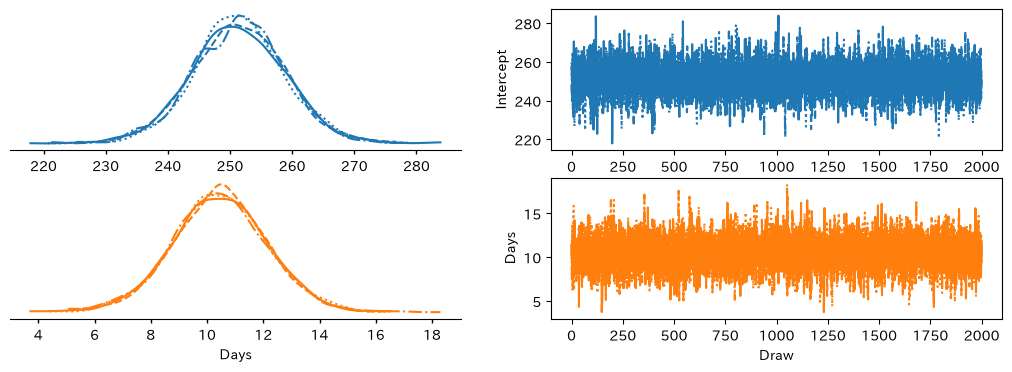

In [23]:
summary_common = azs.summary(idata, var_names=["Intercept", "Days"])
display(summary_common)

ax_common = azp.plot_trace_dist(idata, var_names=["Intercept", "Days"])
ax_common.show()

## 3-3. ランダム効果の確認

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
1|Subject[308],1.1,14,-21,23,10165,6276,1.00,0.14,0.16
1|Subject[309],-40.5,14.6,-64,-18,9144,5900,1.00,0.15,0.16
1|Subject[310],-39.3,14.3,-62,-17,9271,6736,1.00,0.15,0.15


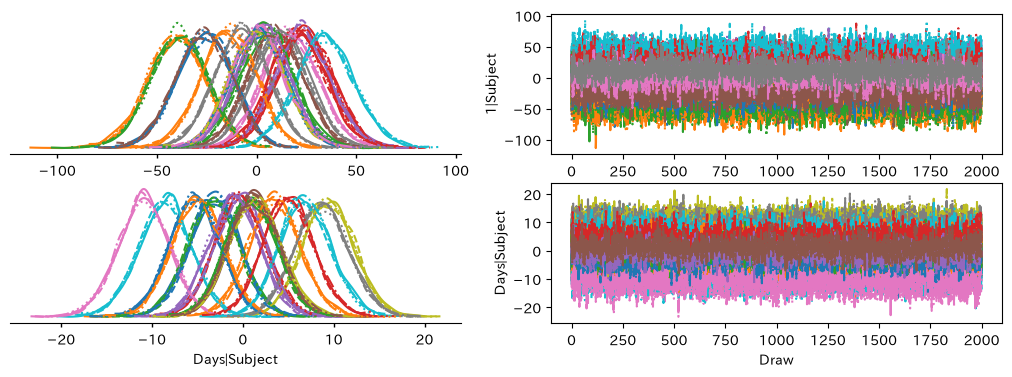

In [28]:
summary_random = azs.summary(idata, var_names=["1|Subject", "Days|Subject"]).head(3)
display(summary_random)

ax_random = azp.plot_trace_dist(idata, var_names=["1|Subject", "Days|Subject"]);
ax_random.show()

## 3-4. Reaction と Days の関係性

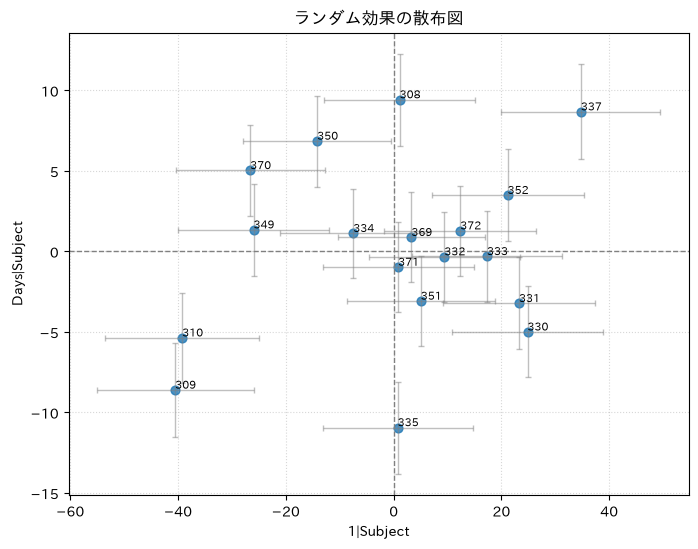

In [66]:
# ランダム効果の平均値を各 Subject ごとに計算
subject = idata.posterior["Subject__factor_dim"].values
b0 = idata.posterior["1|Subject"].mean(dim=("chain", "draw")).values
b1 = idata.posterior["Days|Subject"].mean(dim=("chain", "draw")).values

# 散布図
fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(b0, b1, s=40, alpha=0.8)
# 抽出された posterior sample を使って、各 Subject の不確実性を誤差バーで表す
x_sample = idata.posterior["1|Subject"].values  # (chain, draw, Subject)
y_sample = idata.posterior["Days|Subject"].values  # (chain, draw, Subject)

x_err = x_sample.std(axis=(0, 1))
y_err = y_sample.std(axis=(0, 1))

ax.errorbar(
    b0, b1,
    xerr=x_err, yerr=y_err,
    fmt="none",
    ecolor="gray",
    elinewidth=1,
    alpha=0.5,
    capsize=2
)
# 各点に Subject をラベル付け
for x, y, s in zip(b0, b1, subject):
    ax.text(x, y, str(s), fontsize=8, ha="left", va="bottom")

# 0 を基準に線を入れる
ax.axhline(0, color="gray", linestyle="--", linewidth=1)
ax.axvline(0, color="gray", linestyle="--", linewidth=1)

ax.set_xlabel("1|Subject")
ax.set_ylabel("Days|Subject")
ax.set_title("ランダム効果の散布図")
ax.grid(True, linestyle=":", alpha=0.5)

plt.show()